# 04 - Neural ROI Segmentation and Calcium Trace Extraction

This notebook runs ROI segmentation on the neuron-enhanced movie and audits the extracted spatial footprints, center coordinates, ROI area distribution, and temporal traces.

In [6]:
%matplotlib inline
import os, sys
from pathlib import Path

# Locate the repository root from the current notebook working directory.
def find_repo_root(start):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "Airscope_ca").is_dir() and (path / "configs").is_dir():
            return path
    raise RuntimeError(f"Could not find repo root from {start}")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))

DATA_PATH = "/mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames"
OUT_PATH = DATA_PATH.replace("frames", "Analysis")
print(f"REPO_ROOT : {REPO_ROOT}")
print(f"DATA_PATH : {DATA_PATH}")
print(f"OUT_PATH  : {OUT_PATH}")


REPO_ROOT : /data/home/angran/BBNC/code/PICO_ca_processing_release
DATA_PATH : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames
OUT_PATH  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis


In [7]:
# Compose a reproducible Hydra config for this notebook run.
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=[
            f"data_path={DATA_PATH}",
            f"out_path={OUT_PATH}",
            "motion=suite2p",
            "rmbg=ddp",
        ],
    )

print(OmegaConf.to_yaml(cfg))

motion:
  fr: 10
  mc_chunk_size: 1000
  zarr_chunk_size: 1000
  method: suite2p
  device: cuda
  suite2p:
    align_by_chan2: false
    nimg_init: 400
    maxregshift: 0.1
    do_bidiphase: false
    bidiphase: 0.0
    batch_size: 100
    nonrigid: true
    maxregshiftNR: 5
    block_size:
    - 128
    - 128
    smooth_sigma_time: 0
    smooth_sigma: 1.15
    spatial_taper: 3.45
    th_badframes: 1.0
    norm_frames: true
    snr_thresh: 1.2
    subpixel: 10
    two_step_registration: false
    reg_tif: false
    reg_tif_chan2: false
preprocessing:
  crop_parameter:
  - 153
  - 303
  - 1000
  - 1000
  intensity_corr_flag: false
  bad_frame_detect_flag: false
  preprocess_workers: 64
  preprocess_chunk_size: 512
  zarr_chunk_size: 500
rmbg:
  up_sample: 2
  rmbg_chunk_size: 1000
  zarr_chunk_size: 500
  rmbg_gsize: 6
  batch_size: 8
  print_interval: 20
  use_amp: true
  copy_interval: 4
  num_process_per_gpu: 2
  ckpt_pth: ckpt/background_rejection_ckpt_resize_2.pth
  device: cuda
  

In [8]:
# Imports used by this notebook only.
import os
import logging
from pathlib import Path

from Airscope_ca.process_script import build_paths, setup_logger
from Airscope_ca.pipeline import get_frame_count, extract_neural_signals
from Airscope_ca.utils.io_videos import open_zarr_array
from airscope_notebook_tools import (
    set_publication_style,
    plot_roi_centers,
    plot_roi_area_histogram,
    display_existing_image,
    list_stage_outputs,
)

set_publication_style()
os.makedirs(OUT_PATH, exist_ok=True)
paths = build_paths(cfg)
logger = setup_logger(OUT_PATH)
logger.addHandler(logging.StreamHandler())

frame_count = get_frame_count(cfg)
print(f"Frame count: {frame_count}")
print(f"MC zarr    : {paths.mc_zarr_path}")
print(f"Pre zarr   : {paths.preprocess_zarr_path}")
print(f"RMBG zarr  : {paths.rmbg_zarr_path}")
print(f"Seg out    : {paths.seg_out}")


     4003738 [process_script.py:        setup_logger():87] [2876801] Logging INFO and above from root logger to /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/log_file.log


4000
Frame count: 4000
MC zarr    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/motion_corrected.zarr
Pre zarr   : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocess/video_preprocessed.zarr
RMBG zarr  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr
Seg out    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1


## 1. Inspect Segmentation Input

In [9]:
# Load the neuron-enhanced movie produced by notebook 03.
rmbg_arr = open_zarr_array(paths.rmbg_zarr_path, mode="r")


## 2. Run Neural Signal Extraction

In [10]:
# Run patch-wise ROI segmentation and calcium trace extraction.
print(f"patch_size  : {cfg.segmentation.patch_size}")
print(f"pixel_size  : {cfg.segmentation.pixel_size}")
print(f"thresh_pmap : {cfg.segmentation.thresh_pmap}")

A, C, cm, d1, d2 = extract_neural_signals(cfg, paths, logger)
print(f"A shape: {A.shape}")
print(f"C shape: {C.shape}")
print(f"cm shape: {cm.shape}")

=======>segmentation<=======

     4003770 [extract_neural_signals.py:extract_neural_signals():46] [2876801] =======>segmentation<=======

=======>load RMBG video from Zarr: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr<=======

     4003771 [extract_neural_signals.py:extract_neural_signals():47] [2876801] =======>load RMBG video from Zarr: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr<=======



patch_size  : 500
pixel_size  : 2
thresh_pmap : 1


=======>segment patch 0,0<=======

     4009698 [extract_neural_signals.py:extract_neural_signals():57] [2876801] =======>segment patch 0,0<=======



{'minArea': 50, 'avgArea': 100, 'thresh_pmap': 1, 'thresh_mask': 0.5, 'thresh_COM0': 3.0, 'thresh_COM': 5.0, 'thresh_IOU': 0.5, 'thresh_consume': 0.75, 'cons': 5}
float32
uint8
separate Neurons         : Used  4.859425 s,  1.214856 ms/frame,      44 segmented neurons.
unique_neurons1          : Used  0.446430 s,  0.111607 ms/frame,      34 segmented neurons.


=======>segment patch 0,500<=======

     4018544 [extract_neural_signals.py:extract_neural_signals():57] [2876801] =======>segment patch 0,500<=======



...

{'minArea': 50, 'avgArea': 100, 'thresh_pmap': 1, 'thresh_mask': 0.5, 'thresh_COM0': 3.0, 'thresh_COM': 5.0, 'thresh_IOU': 0.5, 'thresh_consume': 0.75, 'cons': 5}
float32
uint8
separate Neurons         : Used  6.134450 s,  1.533613 ms/frame,   16542 segmented neurons.
unique_neurons1          : Used  0.189561 s,  0.047390 ms/frame,     464 segmented neurons.
group_neurons            : Used  0.193459 s,  0.048365 ms/frame,     251 segmented neurons.
piece_neurons_IOU        : Used  0.032671 s,  0.008168 ms/frame,     243 segmented neurons.
piece_neurons_consume    : Used  0.031009 s,  0.007752 ms/frame,     225 segmented neurons.
refine_seperate          : Used  0.015936 s,  0.003984 ms/frame,     225 segmented neurons.
Total time               : Used  6.599518 s,  1.649880 ms/frame,     225 segmented neurons.
Processing Done: 10.190990 s, 2.547748 ms/frame
Mask saved: 10.492851 s
Final Neuron number:  123
Temporal signal extracted: 10.908031 s
Temporal signal saved: 10.934364 s


=======>segment patch 1500,1500<=======

     4336180 [extract_neural_signals.py:extract_neural_signals():57] [2876801] =======>segment patch 1500,1500<=======



{'minArea': 50, 'avgArea': 100, 'thresh_pmap': 1, 'thresh_mask': 0.5, 'thresh_COM0': 3.0, 'thresh_COM': 5.0, 'thresh_IOU': 0.5, 'thresh_consume': 0.75, 'cons': 5}
float32
uint8
separate Neurons         : Used  5.857705 s,  1.464426 ms/frame,   12802 segmented neurons.
unique_neurons1          : Used  0.245177 s,  0.061294 ms/frame,     272 segmented neurons.
group_neurons            : Used  0.305145 s,  0.076286 ms/frame,     153 segmented neurons.
piece_neurons_IOU        : Used  0.019946 s,  0.004987 ms/frame,     153 segmented neurons.
piece_neurons_consume    : Used  0.019911 s,  0.004978 ms/frame,     144 segmented neurons.
refine_seperate          : Used  0.011831 s,  0.002958 ms/frame,     144 segmented neurons.
Total time               : Used  6.461748 s,  1.615437 ms/frame,     144 segmented neurons.
Processing Done: 9.132423 s, 2.283106 ms/frame
Mask saved: 9.574118 s
Final Neuron number:  94
Temporal signal extracted: 9.802354 s
Temporal signal saved: 9.821696 s


A.shape: (5243, 2000, 2000)
     4352007 [extract_neural_signals.py:extract_neural_signals():85] [2876801] A.shape: (5243, 2000, 2000)
A.dtype: bool
     4352009 [extract_neural_signals.py:extract_neural_signals():86] [2876801] A.dtype: bool
C.shape: (5243, 4000)
     4352009 [extract_neural_signals.py:extract_neural_signals():87] [2876801] C.shape: (5243, 4000)
C.dtype: float32
     4352010 [extract_neural_signals.py:extract_neural_signals():88] [2876801] C.dtype: float32
=======>calculate center of these neurons<=======

     4352010 [extract_neural_signals.py:extract_neural_signals():90] [2876801] =======>calculate center of these neurons<=======

100%|██████████| 6/6 [02:07<00:00, 21.30s/it]


A shape: (5243, 2000, 2000)
C shape: (5243, 4000)
cm shape: (5243, 2)


## 3. Spatial ROI QC without vessel mask filter

Saved summed ROI mask


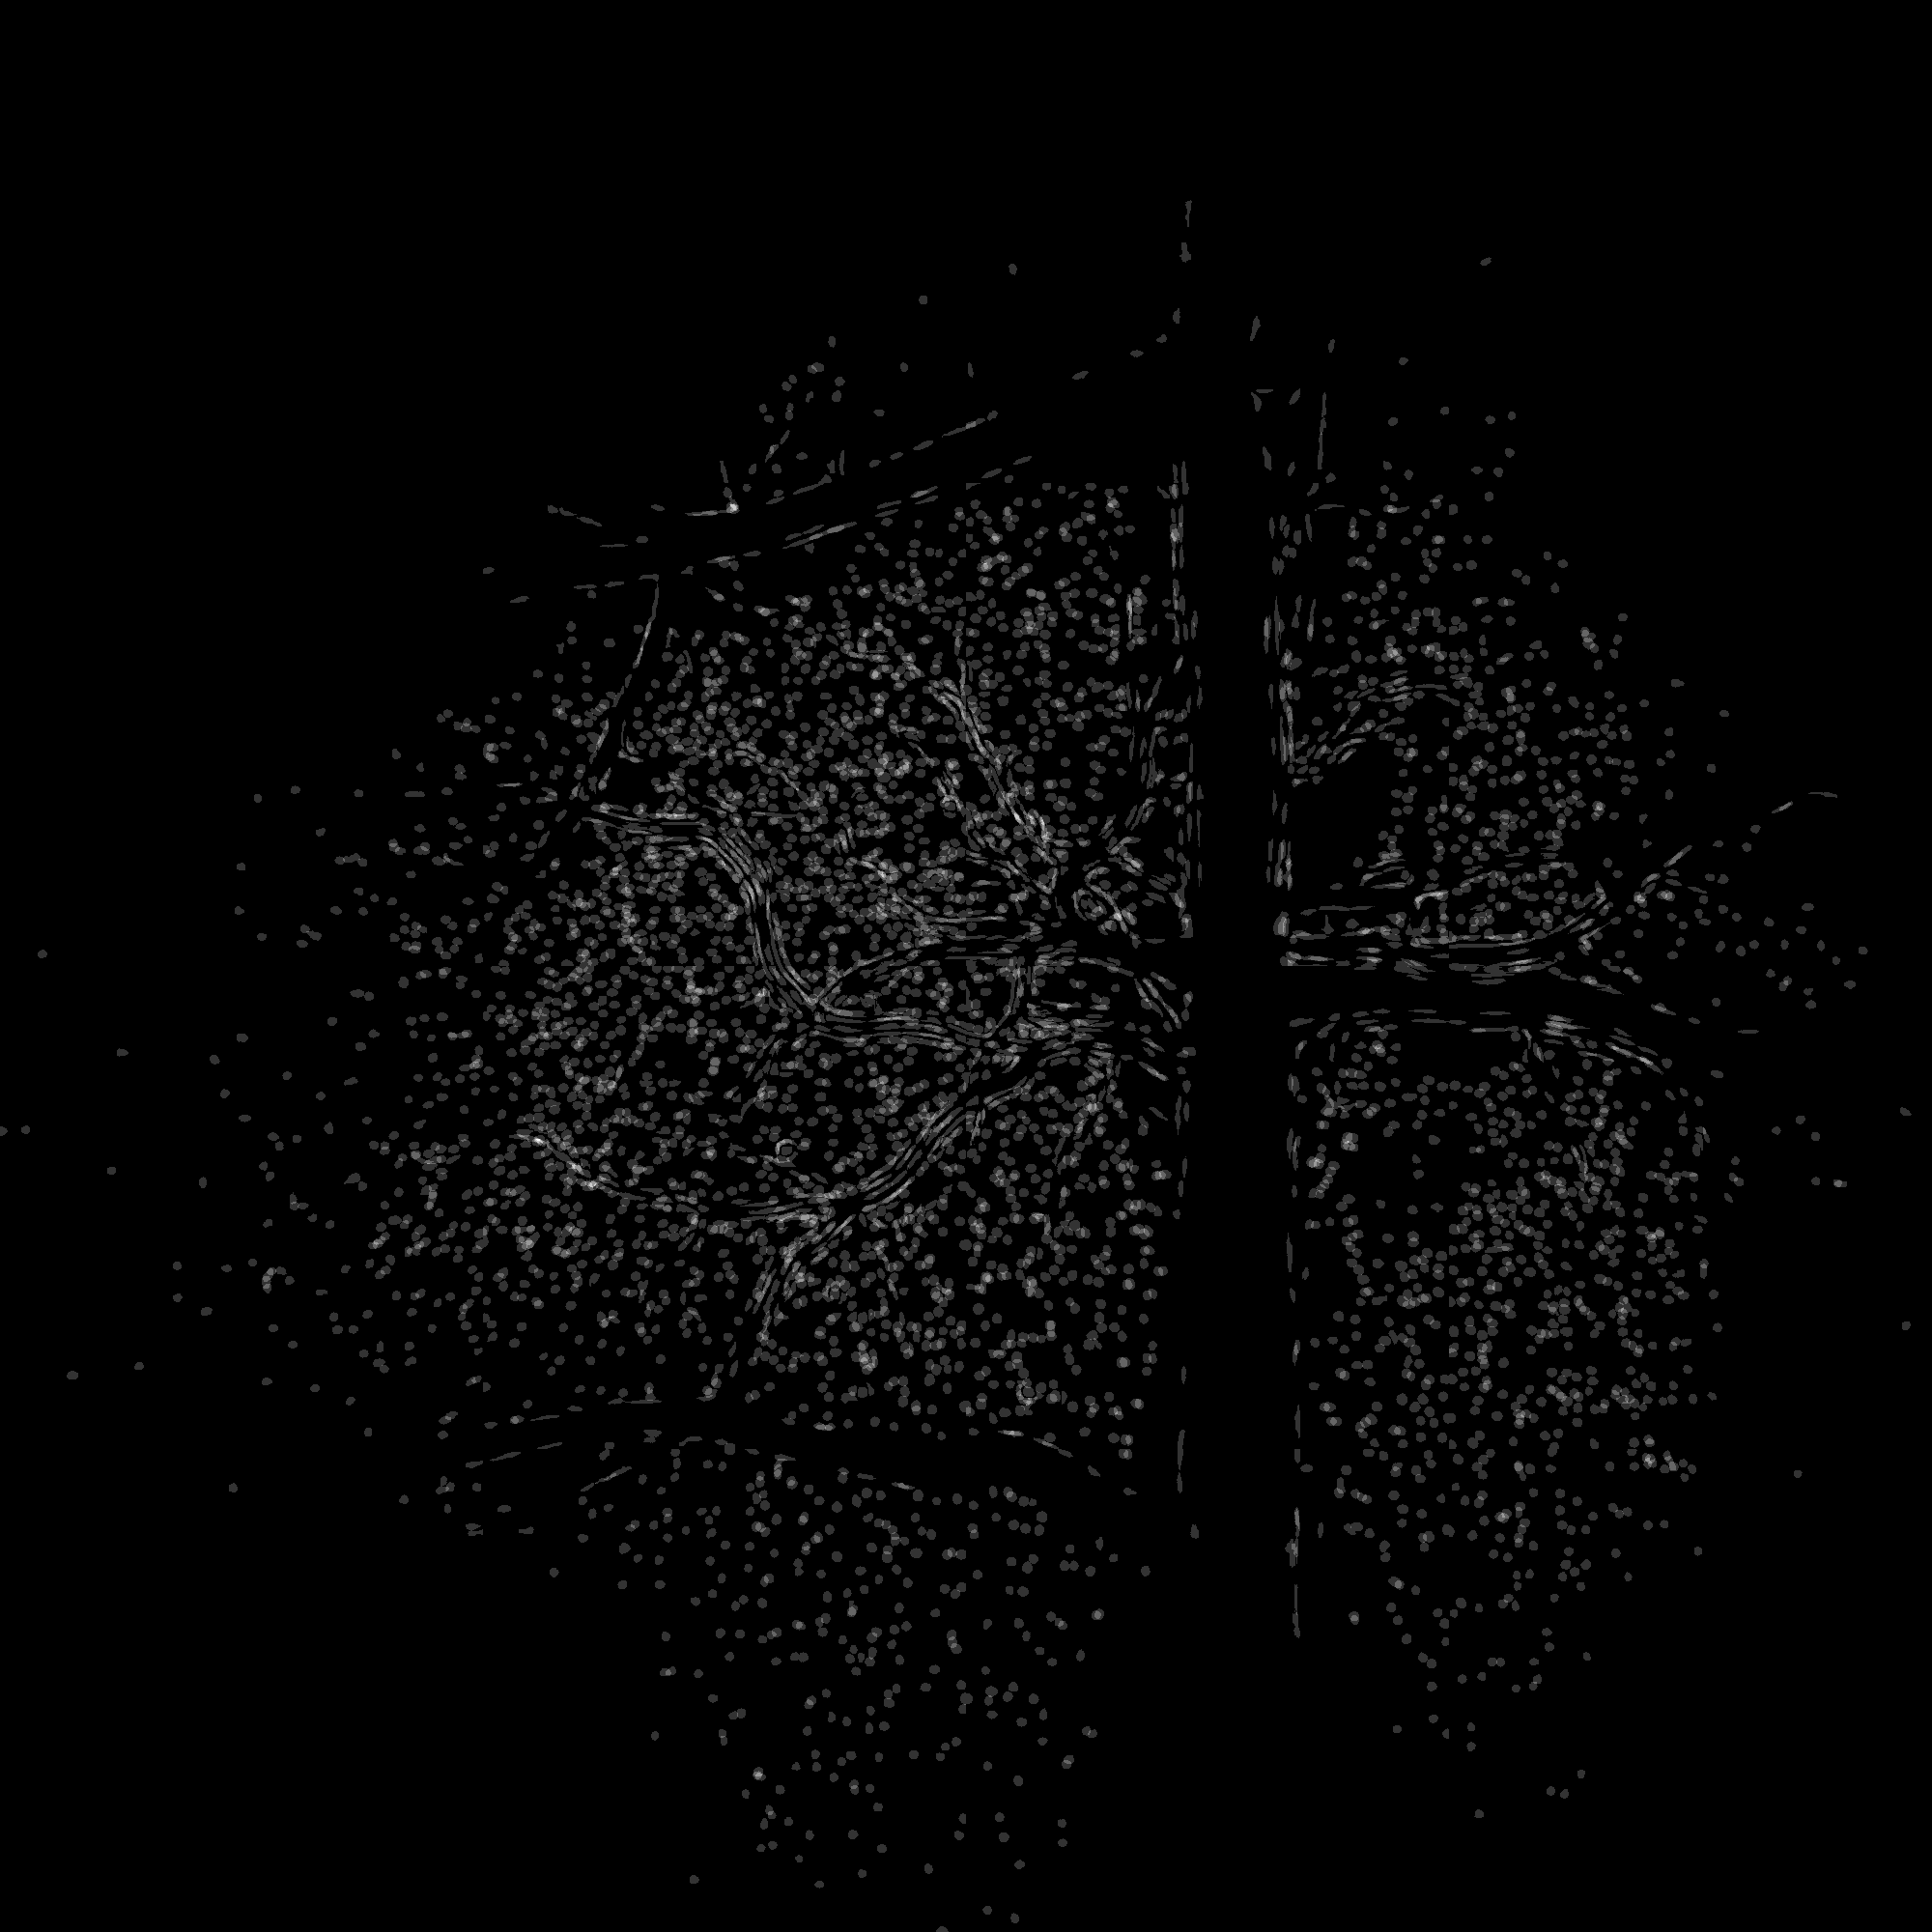

Output directory: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1
SEG_SUM.png
SEG_SUM_filtered.png
cm.mat
cm.png
cm_filtered.mat
cm_wo_vessel.png
infer_results.mat
infer_results_filtered.mat
neuron_mask.png
seg_results.mat
seg_results_filtered.mat


[PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/SEG_SUM.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/SEG_SUM_filtered.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm.mat'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm_filtered.mat'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/cm_wo_vessel.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/infer_results.mat'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/infer_results_filtered.mat'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1/neuron_mask.png'),
 PosixPath('/mnt/nas02/LAR/pico

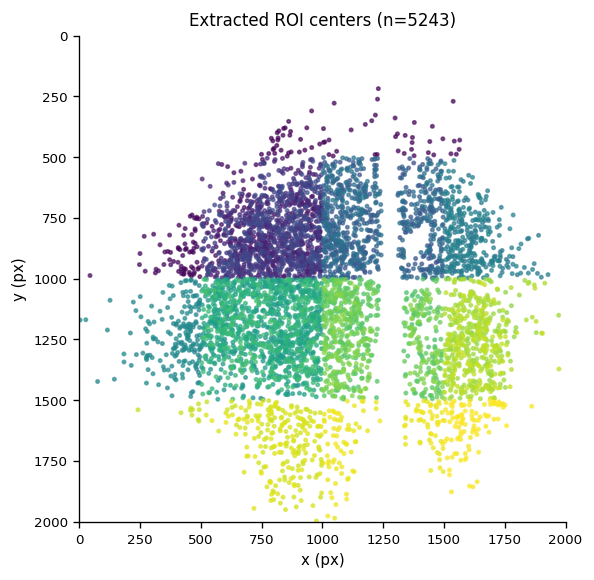

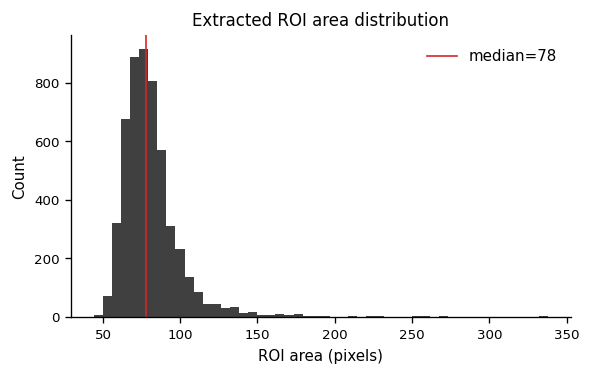

In [11]:
# Review spatial ROI distribution before vessel and shape filtering.
_ = plot_roi_centers(cm, d1, d2, title="Extracted ROI centers")
_ = plot_roi_area_histogram(A, title="Extracted ROI area distribution")
display_existing_image(Path(paths.seg_out) / "SEG_SUM.png", title="Saved summed ROI mask")
list_stage_outputs(paths.seg_out, patterns=("*.png", "*.mat"), max_items=50)